In [ ]:
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import sys
import time
import tensorflow.keras as keras
import tensorflow as tf
import re
import csv

from PIL import Image
from tensorflow.keras.applications import MobileNetV2
from keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, Input, GlobalAveragePooling2D
# from keras.layers.experimental.preprocessing import Normalization
from keras.models import Model, Sequential
from keras.preprocessing import image
from keras.utils import to_categorical
from keras.layers import Lambda
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
# prompt: generate code to mount drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Data Processing

In [ ]:
# def get_image_paths(root_dir):
#     image_paths = []
#     for dirpath, _, filenames in os.walk(root_dir):
#         for filename in filenames:
#             if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
#                 image_path = os.path.join(dirpath, filename)
#                 label = os.path.basename(dirpath)
#                 image_paths.append((image_path, label))
#     return image_paths

# def write_to_csv(image_paths, csv_filename):
#     with open(csv_filename, 'w', newline='') as csvfile:
#         csv_writer = csv.writer(csvfile)
#         csv_writer.writerow(['image_path', 'label'])
#         csv_writer.writerows(image_paths)

# # Example usage
# root_directory = '/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Garbage_Classification_Dataset_LPD'
# csv_filename = '/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Garbage_Classification_Dataset_LPD/garbage_dataset.csv'

# image_paths = get_image_paths(root_directory)
# write_to_csv(image_paths, csv_filename)


In [ ]:
base_path = "/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Garbage_Classification_Dataset_LPD"

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Garbage_Classification_Dataset_LPD/garbage_dataset.csv")
df.drop(["Unnamed: 0"], axis=1, inplace=True)
df = df.rename(columns={"image_path": "filename", "label": "category"})
df.head()

,filename,category
0,/content/drive/MyDrive/LetsPrompt Fiverr Proje...,4
1,/content/drive/MyDrive/LetsPrompt Fiverr Proje...,4
2,/content/drive/MyDrive/LetsPrompt Fiverr Proje...,1
3,/content/drive/MyDrive/LetsPrompt Fiverr Proje...,1
4,/content/drive/MyDrive/LetsPrompt Fiverr Proje...,3


In [ ]:
categories = {"papers": 0,"glass": 1,"plastics": 2,"metals": 3,"biodegradables": 4, "cardboards": 5}

In [ ]:
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS = 3

### Data Visualization

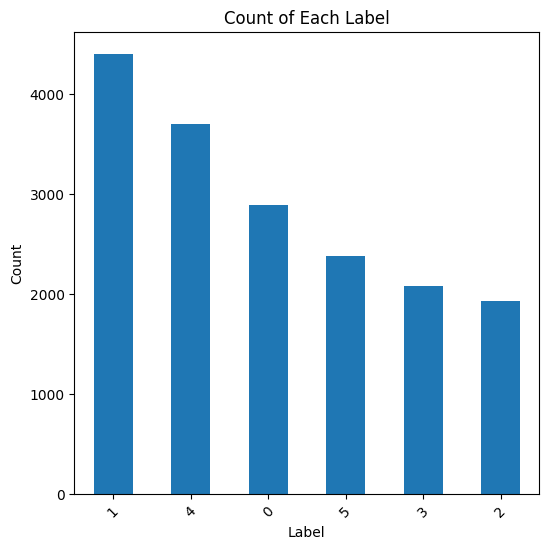

In [ ]:
label_counts = df['category'].value_counts()

plt.figure(figsize=(6, 6))
label_counts.plot(kind='bar')
plt.title('Count of Each Label')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Model Development

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization
import keras.applications.mobilenet_v2 as mobilenetv2

mobilenetv2_layer = mobilenetv2.MobileNetV2(include_top = False, input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT,IMAGE_CHANNELS),
                       weights = '/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/MobileNet_Base_Model/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5')

# We don't want to train the imported weights
mobilenetv2_layer.trainable = False


model = Sequential()
model.add(keras.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)))

In [ ]:
#create a custom layer to apply the preprocessing
def mobilenetv2_preprocessing(img):
  return mobilenetv2.preprocess_input(img)

model.add(Lambda(mobilenetv2_preprocessing))

model.add(mobilenetv2_layer)
model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dropout(0.2))
model.add(Dense(len(categories), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['categorical_accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 6)                 7686      
                                                                 
Total params: 2,265,670
Trainable params: 7,686
Non-trai

In [ ]:
early_stop = EarlyStopping(patience = 5, verbose = 1, monitor='val_categorical_accuracy' , mode='max', min_delta=0.001, restore_best_weights = True)

callbacks = [early_stop]

print('Call Back Defined!')

Call Back Defined!


In [ ]:
from sklearn.model_selection import train_test_split

# Change the categories from numbers to names
df["category"] = df["category"].replace(categories)

# We first split the data into two sets and then split the validate_df to two sets
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
validate_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

total_train = train_df.shape[0]
total_validate = validate_df.shape[0]

print('train size = ', total_train , 'validate size = ', total_validate, 'test size = ', test_df.shape[0])

train size =  10419 validate size =  3473 test size =  3473


In [ ]:
train_df['category'] = train_df['category'].astype(str)
validate_df['category'] = validate_df['category'].astype(str)
test_df['category'] = test_df['category'].astype(str)

In [ ]:
batch_size=64
train_datagen = image.ImageDataGenerator()


train_generator = train_datagen.flow_from_dataframe(
    train_df,
    base_path,
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)

Found 10419 validated image filenames belonging to 6 classes.


In [ ]:
validation_datagen = image.ImageDataGenerator()

validation_generator = validation_datagen.flow_from_dataframe(
    validate_df,
    base_path,
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)

Found 3473 validated image filenames belonging to 6 classes.


In [ ]:
EPOCHS = 40
history = model.fit_generator(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=total_validate//batch_size,
    steps_per_epoch=total_train//batch_size,
    callbacks=callbacks
)

<ipython-input-16-8a9126ffe14c>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/40
162/162 [==============================] - 9603s 59s/step - loss: 0.6718 - categorical_accuracy: 0.7570 - val_loss: 0.3749 - val_categorical_accuracy: 0.8715
Epoch 2/40
162/162 [==============================] - 168s 1s/step - loss: 0.3652 - categorical_accuracy: 0.8717 - val_loss: 0.3323 - val_categorical_accuracy: 0.8819
Epoch 3/40
162/162 [==============================] - 173s 1s/step - loss: 0.3137 - categorical_accuracy: 0.8913 - val_loss: 0.3023 - val_categorical_accuracy: 0.8955
Epoch 4/40
162/162 [==============================] - 169s 1s/step - loss: 0.2875 - categorical_accuracy: 0.9016 - val_loss: 0.2883 - val_categorical_accuracy: 0.8953
Epoch 5/40
162/162 [==============================] - 161s 992ms/step - loss: 0.2640 - categorical_accuracy: 0.9075 - val_loss: 0.2828 - val_categorical_accuracy: 0.9019
Epoch 6/40
162/162 [==============================] - 161s 992ms/step - loss: 0.2515 - categorical_accuracy: 0.9142 - val_loss: 0.2822 - val_categorical_accurac